# normalization with uMAIA, making two sections comparable

In notebook N1 you pulled raw MALDI images from METASPACE, and in N2 you turned those peaks into named
lipids. You now hold, for each of our two coronal sections, a table of pixels by lipids. One section is
a control female brain, the other a pregnant female brain, cut at the *same* coronal plane (roughly
6.5 mm behind bregma). The whole course builds toward one question: which lipids change in the brain
during pregnancy, and where? Before we can answer it, we have to make the two sections honestly
comparable, because they were acquired on different days, on different slides, and the instrument does
not give the same number twice for the same amount of lipid.

That is what this notebook is about. We meet the **batch effect**, the technical drift that separates
two acquisitions; we look at the empirical structure of MALDI data that makes it correctable; we read
the **uMAIA** model that exploits that structure; and then we actually run uMAIA on our two sections,
watch the slide-to-slide offset shrink, and confirm that the white-matter sphingolipid signal lines up
across sections afterwards. We unroll uMAIA's correction by hand so it stops being a black box, and we
are honest about what it can and cannot do when you hand it only two sections instead of a stack.

## the callouts

The same four markers run through every notebook in this course:

- 🔬 **TASK**: something you do (write or run code).
- 💡 **HINT**: a nudge when you are stuck.
- ❓ **QUESTION**: pause and think; no code required.
- **check.**: what you should see if it worked. If your screen disagrees, stop and reconcile it before moving on.

🔬 **TASK.** Run the next cell to load the libraries and set the course plotting style.

In [1]:
# --- this notebook RUNS uMAIA for real, on the cajal-umaia kernel ---
# uMAIA's fit is JAX/NumPyro. The course cluster has no GPU, so we pin JAX to the CPU.
# This MUST happen before anything imports jax (uMAIA does, on import), so it is the
# very first line of the notebook.
import os
os.environ["JAX_PLATFORMS"] = "cpu"

# the scientific-Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from scipy import stats                      # the normal CDF for the histogram-matching transform
from scipy.interpolate import interp1d

# uMAIA itself (only this kernel has it installed)
import uMAIA

# the course helper package + shared plotting style
import sys; sys.path.insert(0, os.path.abspath("../../src"))
from cajal_lipidomics import analysis
from cajal_lipidomics.plotting import FS
from cajal_lipidomics.style import set_style, CMAP_SEQUENTIAL
set_style()

DATA = os.path.abspath("../../data")
RNG_SEED = 42
import jax
print(f"ready. numpy {np.__version__} | anndata {ad.__version__} | JAX on {jax.devices()[0].platform}")

/home/fusar/mambaforge/envs/cajal-umaia/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ready. numpy 1.26.4 | anndata 0.11.4 | JAX on cpu


**check.** You should see `ready. numpy ... | anndata ... | JAX on cpu` and no red error. This
notebook runs on the **`cajal-umaia`** kernel, not `cajal-lipidomics`: it is the only one with JAX,
NumPyro and uMAIA installed. If you get `ModuleNotFoundError: No module named 'uMAIA'`, you are on the
wrong kernel; pick `cajal-umaia` in the top-right kernel picker and rerun. The `JAX on cpu` at the end
confirms we pinned JAX to the CPU, because the course cluster has no GPU.

## the two sections, straight from N2

We pick the chain up exactly where N2 left it: `data/derived/02_annotated.h5ad`. This is *your* output
from the previous notebook, the annotated substrate, one AnnData holding both sections stacked together.
`adata.X` is the matrix of pixels by lipids, still on its **raw** intensity scale (nothing has been
normalized yet), `adata.var` carries the lipid names you assigned, and `adata.obs` carries the per-pixel
metadata: which condition, which section, and where each pixel sits in the Allen brain atlas.

🔬 **TASK.** Load it and read off the shape.

In [2]:
# the annotated two-section substrate from N2 (pixels x lipids), raw intensities
adata = ad.read_h5ad(os.path.join(DATA, "derived", "02_annotated.h5ad"))

n_pixels, n_lipids = adata.shape
print(f"{n_pixels:,} pixels  x  {n_lipids} lipids")
print()
print("pixels per condition:")
print(adata.obs["Condition"].value_counts())
print()
print("a few lipid names:", [l for l in adata.var["lipid"] if not l.startswith("ion_")][:6])
print("X range:", float(np.asarray(adata.X).min()), "to", float(np.asarray(adata.X).max()))

189,011 pixels  x  104 lipids

pixels per condition:
Condition
pregnant    100258
naive        88753
Name: count, dtype: int64

a few lipid names: ['LPC 15:1', 'LPE 21:1', 'PA 34:2', 'PA 34:1', 'PC 30:0', 'PA 36:2']
X range: 0.0 to 1.0


**check.** 189,011 pixels and 104 lipids, split into `naive` (the control female, about 89k
pixels) and `pregnant` (about 100k pixels). The lipid names read as a class plus a chain summary:
`HexCer 42:2` is a hexosylceramide with 42 acyl carbons and 2 double bonds, a sphingolipid that marks
myelin; we met that naming in N2. `X` runs from 0 to 1 because the ion images arrive from METASPACE as
8-bit intensity images, scaled into [0, 1] per image. That is the raw scale we start from. The
quantization is fine for everything below.

## what a batch effect is, in one picture

MALDI-MSI acquires one mass spectrum per pixel. A whole tissue section is one **acquisition**: one
laser run, one matrix coating, one instrument session. Between acquisitions several non-biological
things drift:

- **matrix crystallization**: the light-absorbing matrix is sprayed onto the slide and crystallizes;
  thicker or finer crystals desorb more or less material.
- **laser energy**: the pulse energy is not identical shot to shot or day to day.
- **detector gain and ionization efficiency**: the electronics and the ionization yield wander.
- **sample handling**: thaw-mounting, storage time, humidity.

None of these has anything to do with biology, yet all of them move the measured intensity of a given
lipid up or down by a roughly section-wide factor. That is the **batch effect**: a technical, mostly
multiplicative shift that affects one whole acquisition relative to another. If we compared our control
and pregnant sections without correcting it, part of every difference we found would just be "the
pregnant slide ran hotter", and we would have no way to tell that apart from real biology.

The saving grace is the experimental design. The two sections are cut at the same coronal plane, so the
**anatomy is matched**: the same regions, in the same places, in both. When the anatomy is held fixed,
any blanket intensity difference between the slides is suspicious, and that is exactly the handle a
normalizer can grab. Let us look at the two sections first, painted by Allen region, to see how well
the anatomy lines up.

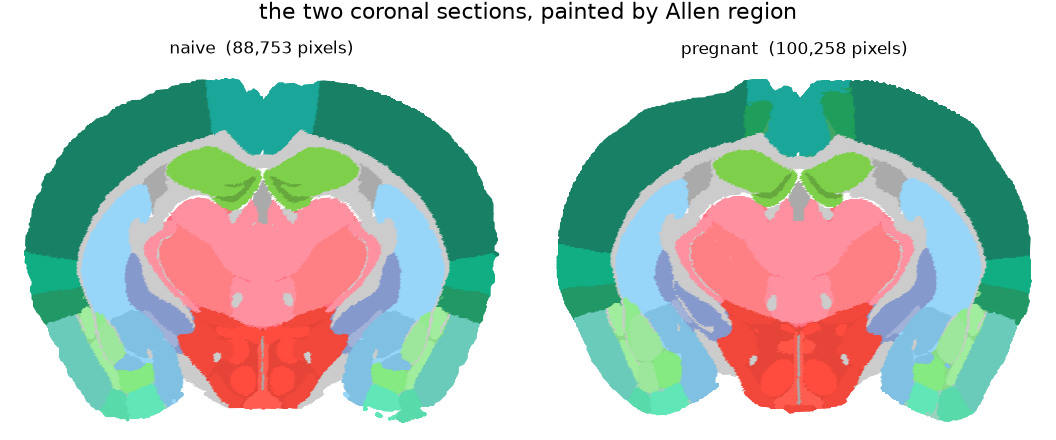

In [3]:
# plot both sections coloured by Allen anatomical region (the provided per-pixel colours)
secs = ["naive", "pregnant"]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, cond in zip(axes, secs):
    m = (adata.obs["Condition"] == cond).to_numpy()
    ax.scatter(adata.obs.loc[m, "zccf"], -adata.obs.loc[m, "yccf"],
               c=adata.obs.loc[m, "allencolor"], s=2, rasterized=True)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"{cond}  ({m.sum():,} pixels)", fontsize=FS["m"])
fig.suptitle("the two coronal sections, painted by Allen region", fontsize=FS["l"])
plt.tight_layout(); plt.show()

**check.** Two coronal brain slices of nearly identical shape, painted in the Allen colour scheme.
Same plane, same anatomy, different mouse and different acquisition. That is the ideal setup for spotting
a batch effect: when the *anatomy* is matched, any blanket intensity difference between the slides is
technical, not biological.

❓ **QUESTION.** A batch effect shifts a whole section's intensity scale at once. A real biological
difference changes specific lipids in specific places. Keep that contrast in mind: normalization tries
to remove the first without touching the second. How might a method possibly tell them apart from the
data alone? The next section gives uMAIA's answer.

## the key empirical fact: per-molecule histograms are bimodal in log space

uMAIA does not just rescale each image by a constant. It leans on a specific structure that real MALDI
data has. Take one lipid, collect its intensity across all the pixels of one section, and plot the
histogram **in log space**. You typically see *two humps*, not one:

- a low **background mode**: pixels where this lipid is essentially absent, so you are measuring matrix
  noise and baseline. These pixels pile up at a low, roughly fixed value.
- a higher **foreground mode**: pixels where the lipid is genuinely present, at a level set by the
  tissue's biology.

Why log space? Because intensities span orders of magnitude and the interesting structure is
multiplicative. On a linear axis everything crushes against zero and the two humps merge into one spike.
On a log axis they separate and you can see them. Let us look at one myelin sphingolipid, `HexCer 42:2`,
in the control section.

fraction of control pixels at the background floor: 38%


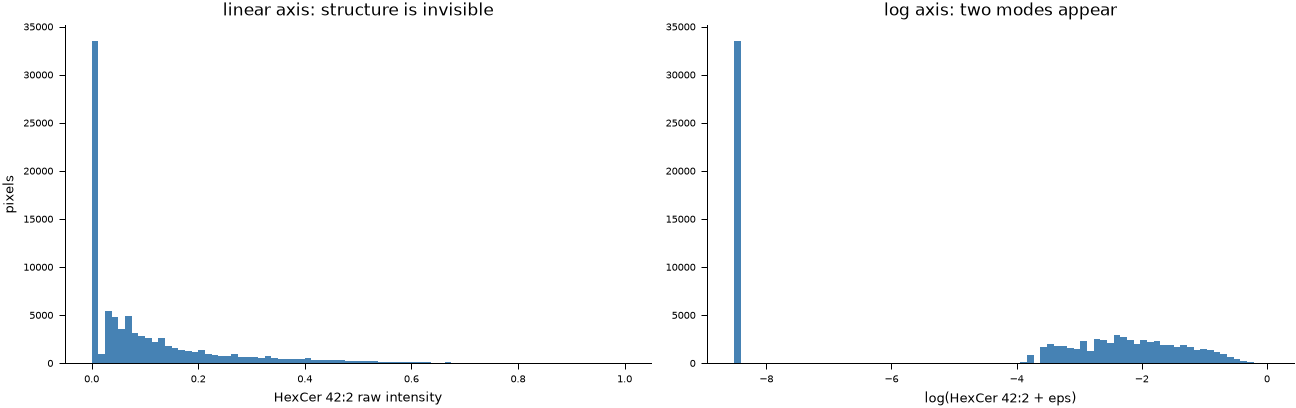

In [4]:
# pick one lipid and one section; collect its intensities across all pixels
lipid = "HexCer 42:2"
j = list(adata.var["lipid"]).index(lipid)
X = np.asarray(adata.X)                        # pixels x lipids, raw scale
eps = 2e-4                                      # uMAIA's log offset (mirrors build_umaia_input.py)

m_ctrl = (adata.obs["Condition"] == "naive").to_numpy()
vals = X[m_ctrl, j]                             # this lipid's intensity in every control pixel
log_vals = np.log(np.clip(vals, 0, None) + eps)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(vals, bins=80, color="steelblue")
axes[0].set_title("linear axis: structure is invisible", fontsize=FS["m"])
axes[0].set_xlabel(f"{lipid} raw intensity"); axes[0].set_ylabel("pixels")
axes[1].hist(log_vals, bins=80, color="steelblue")
axes[1].set_title("log axis: two modes appear", fontsize=FS["m"])
axes[1].set_xlabel(f"log({lipid} + eps)")
floor = np.log(eps) + 0.3
print(f"fraction of control pixels at the background floor: {(log_vals < floor).mean():.0%}")
plt.tight_layout(); plt.show()

**check.** On the linear axis everything crushes against zero. On the log axis you see the
structure: a sharp spike at the very bottom (the background floor, where the lipid is absent, about a
third of pixels) and a broad hump to the right (the foreground, the white-matter pixels where this
myelin lipid is genuinely abundant). Not every lipid is this clearly bimodal, but many are, and that is
the structure uMAIA exploits.

The crucial asymmetry, established in the uMAIA paper: **the batch effect acts mostly on the foreground
mode.** The background mode is matrix noise and stays roughly put from slide to slide; it is a stable
anchor. The foreground mode is real signal, and that is where the technical gain wanders. So the
correction we want is not "shift everything by a constant"; it is "hold the background anchor, and slide
the foreground mode back into register". Keep that picture: anchor low, drift high.

🔬 **TASK.** Now overlay the *same lipid* from the two sections, in log space, to see whether their
foreground modes sit at the same place. This is the batch effect, if it is there.

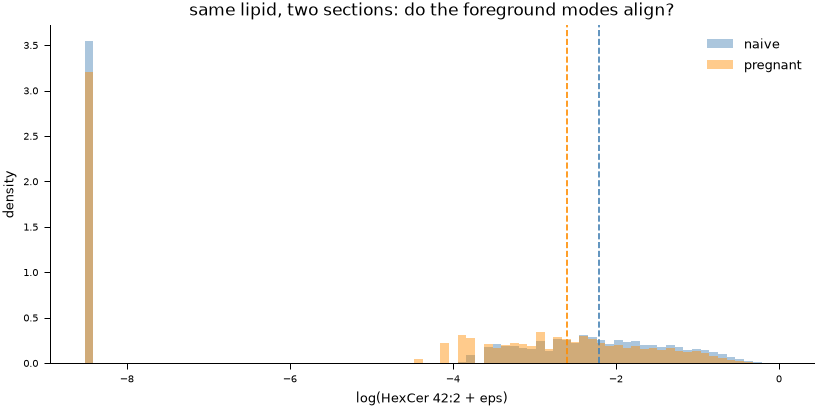

In [5]:
# overlay the log histogram of the SAME lipid in the two sections
fig, ax = plt.subplots(figsize=(7, 3.6))
for cond, colour in [("naive", "steelblue"), ("pregnant", "darkorange")]:
    m = (adata.obs["Condition"] == cond).to_numpy()
    lv = np.log(np.clip(X[m, j], 0, None) + eps)
    ax.hist(lv, bins=80, density=True, histtype="stepfilled", alpha=0.45, color=colour, label=cond)
    fg = lv[lv > floor]
    ax.axvline(np.median(fg), color=colour, ls="--", lw=1)     # each section's foreground median
ax.set_xlabel(f"log({lipid} + eps)"); ax.set_ylabel("density")
ax.set_title("same lipid, two sections: do the foreground modes align?", fontsize=FS["m"])
ax.legend(frameon=False, fontsize=FS["s"])
plt.tight_layout(); plt.show()

**check.** The two background floors sit on top of each other (the anchor), but the two foreground
humps do *not* quite line up; the dashed lines mark each section's foreground median and they are
visibly offset, on the order of 0.2 to 0.4 log units. That gap is the thing we have to worry about. Some
of it might be real (pregnancy could genuinely change this lipid) and some is technical drift, and on
this raw data the two are tangled together. Normalization's job is to remove the technical part while
disturbing the biological part as little as possible. To see how, we need the model.

## the uMAIA model: a mixture per (lipid, section), with a rank-1 batch term

uMAIA fits, for every (lipid, section) pair, a **two-component Gaussian mixture in log space**: one
Gaussian for the background mode, one for the foreground mode. The clever part is how the foreground
mode's position is parameterized. Write `x` for a pixel's log-intensity of compound `c` in acquisition
(section) `a`. The generative model, read off uMAIA's `_model.py` on its default path
(`delta_v_dist='gaussian'`, the branch `normalize()` actually passes), is:

```
# --- per-lipid parameters: one value per compound c, SHARED across sections ---
delta_v_c ~ Gamma(5.0, 2.0)           # prior mean 2.5: the typical fg-minus-bg gap on the log scale
delta_c   ~ Normal(delta_v_c, 0.25)   # this lipid's mode gap, tight around delta_v_c
locs_c    ~ Normal(m0, 1)             # background mean = the anchor, ONE per lipid (not per section)
sigma0_c  ~ Uniform(0.05, 0.5)        # background sd (uMAIA stores this under the param name `scale1`)
lambda_c  ~ Uniform(-2, 2)            # how susceptible THIS lipid is to batch drift
sigma_v_c ~ Exponential(.)            # per-lipid piece of the foreground sd

# --- per-section parameters: one value per acquisition a ---
gamma_a   ~ Uniform(-2, 2)            # how strong the drift is on THIS slide
sigma_s_a ~ Exponential(.)            # per-slide piece of the foreground sd

# --- per (lipid, section) slack on the batch shift ---
error_ac  ~ Uniform(-0.5, 0.5)        # small wiggle that soaks up departures from the strict rank-1 shift

# --- assembled per (lipid, section) ---
mu0_ac    = locs_c                                              # background mean (the anchor), per lipid
mu1_ac    = locs_c + gamma_a * lambda_c + delta_c + error_ac    # foreground mean
sigma1_ac = sigma_s_a + sigma_v_c                              # foreground sd, built ADDITIVELY
pi_ca     ~ Dirichlet(0.5, 0.5)       # mixture weights: how much background vs foreground
z_p       ~ Bernoulli(pi_ca)          # per-pixel latent label: is this pixel bg or fg?
x_p       ~ z * Normal(mu1_ac, sigma1_ac) + (1 - z) * Normal(mu0_ac, sigma0_c)
```

A note on what is per-lipid versus per-section, because it is easy to get wrong: in the code `locs`
(the background anchor) is sampled **per lipid only**, one vector over compounds, not one per (lipid,
section). The parameters that carry a section index are `gamma_a`, `sigma_s_a`, and the small per-(lipid, section) slack `error_ac`. So the background
mean of a given lipid is the same value the model places under every section's background hump, which
is exactly what makes it an anchor.

Read the foreground-mean line slowly, because it is the heart of the method:

$$\mu^{1}_{ac} \;=\; \underbrace{\text{locs}_{c}}_{\text{background anchor (per lipid)}} \;+\; \underbrace{\gamma_a \cdot \lambda_c}_{\text{batch shift}} \;+\; \underbrace{\delta_c}_{\text{biological mode gap}}$$

The code carries one term the picture above leaves out, a small per-(lipid, section) slack
`error_ac ~ Uniform(-0.5, 0.5)` added to the same foreground mean. It absorbs the bit of drift the
strict rank-1 product cannot, and the correction removes it together with `gamma_a * lambda_c`, so it
changes nothing about the logic below; the three labelled terms are what to hold onto.

The batch shift is **rank-1**: one scalar per slide, `gamma_a`, times one scalar per lipid, `lambda_c`.
That factorization is the modeling assumption that does all the work. It says every slide has a single
"how bad is my drift" number, and every lipid has a single "how much do I respond to drift" number, and
the shift on a given (slide, lipid) is just their product. The paper justifies this empirically: take
the matrix of measured technical errors and do an SVD, and the first singular value dominates, meaning
one slide-factor times one lipid-factor explains most of the technical variance.

`delta_c` is the systematic, biological distance between the background and foreground modes, the same
across slides for a given lipid. So the foreground mean is the background anchor, plus a biological gap
that should not be touched, plus a technical shift that should be removed. Normalization removes
`gamma_a * lambda_c` and leaves `delta_c` and the anchor in place. The foreground standard deviation is
built **additively**, `sigma1 = sigma_s_a + sigma_v_c`, a per-slide piece plus a per-lipid piece; this
is an implementation detail, the rank-1 batch shift is the idea to remember.

### how it is fit: MAP via SVI, not posterior sampling

uMAIA fits this model with **stochastic variational inference (SVI)** using an `AutoDelta` guide. That
phrase has a simple meaning. A delta-function guide collapses the "posterior" to a single point, so SVI
here is doing **maximum-a-posteriori (MAP)** estimation: it finds the single most probable set of
parameter values, with the priors acting as gentle regularizers, by gradient descent (Adam). There is
**no MCMC and there are no posterior samples.** Think "regularized best-fit point estimate", not
"Bayesian sampling". The discrete per-pixel labels `z` are marginalized analytically by enumeration, so
the optimizer only ever sees continuous parameters. With a fixed seed the result is deterministic.

The three calls, mirroring `scripts/run_umaia.py`:

1. `uMAIA.norm.initialize(x, mask, subsample=True)` does the **GMM initialization**: per molecule, fit
   a one- and a two-component Gaussian mixture and keep the lower-BIC one. This is where the background
   and foreground modes the model starts from come from.
2. `uMAIA.norm.normalize(...)` is the only heavy step: the **MAP fit via SVI**, `num_steps=2000`,
   `seed=42`, `covariate_vector=None` (more on that choice below). It subsamples about 2,500 pixels per
   section, so on a CPU it finishes in a couple of minutes.
3. `uMAIA.norm.transform(x, mask, params)` applies the **histogram-matching correction** (the
   CDF/inverse-CDF map we unroll by hand further down) and returns the normalized log tensor.

## building uMAIA's input tensor from our AnnData

uMAIA normalizes the **same molecule across sections**, so its input is not a flat pixels-by-lipids
matrix; it is a three-dimensional tensor `x` of shape `(N_pixels, S_sections, V_molecules)`, plus a
boolean `mask` marking which pixel slots are real (the two sections have different pixel counts, so the
shorter one is padded). For each section we take that section's pixels, log-transform the raw
intensities with the same `eps = 2e-4` offset, and stack them along the section axis. This mirrors
`scripts/build_umaia_input.py` exactly, except we read the ions straight from the AnnData you already
loaded instead of re-pulling them from METASPACE.

🔬 **TASK.** Build the tensor, then run the three uMAIA calls. The fit will print a tqdm progress bar
with a falling loss; that is SVI walking the parameters downhill toward their most probable values. The loss it reports is the negative ELBO, the objective variational inference optimizes; with the point-estimate (`AutoDelta`) guide used here, minimizing it is just gradient descent to the MAP fit. Let the bar fill (a couple of minutes).

💡 **HINT: read the code you are about to run.** Before you press shift-enter on the fit, open and read **`scripts/run_umaia.py`**: it is the exact three-call recipe (`initialize` -> `normalize` -> `transform`) you are about to reproduce inline, plus the parameter-saving (`uMAIA.ut.tools.save_svi`) and the same before/after money plot. The tensor builder it feeds from is **`scripts/build_umaia_input.py`**; open that too and check the `eps = 2e-4` log offset and the `(N, S, V)` padding match what the next cell does. You will never be asked to run a black box in this course without first being shown the box.

In [6]:
# --- build the (N_pixels, S_sections, V_molecules) tensor from adata.X ---
molecules = list(adata.var_names)                       # the formula__adduct keys
sections = ["naive", "pregnant"]                         # section axis order (s=0 naive, s=1 pregnant)
cond = adata.obs["Condition"].to_numpy()
per_section_masks = [cond == s for s in sections]
counts = [int(m.sum()) for m in per_section_masks]       # pixels in each section

N = max(counts); S = len(sections); V = len(molecules)
x = np.zeros((N, S, V), np.float32)                      # log-intensities, padded
mask = np.zeros((N, S, V), bool)                         # True where a pixel is real
for s, m in enumerate(per_section_masks):
    xs = np.log(np.clip(X[m], 0, None) + eps)            # this section: log raw intensities
    n = xs.shape[0]
    x[:n, s, :] = xs
    mask[:n, s, :] = True
print(f"tensor x {x.shape} (N, S, V) | {V} molecules | sections {sections} | pixels {counts}")

# --- the REAL uMAIA fit, exactly as in scripts/run_umaia.py ---
print("initialize (GMM per molecule)...")
init = uMAIA.norm.initialize(x, mask, subsample=True)
print("normalize (MAP via SVI, 2000 steps)...")
svi = uMAIA.norm.normalize(x, mask, init_state=init, subsample=True, num_steps=2000, seed=RNG_SEED)
print("transform (histogram matching)...")
x_maia = np.asarray(uMAIA.norm.transform(x, mask, svi))  # normalized log tensor, same shape as x
print("done. x_maia", x_maia.shape)

tensor x (100258, 2, 104) (N, S, V) | 104 molecules | sections ['naive', 'pregnant'] | pixels [88753, 100258]
initialize (GMM per molecule)...


GMM Initialization:   0%|          | 0/104 [00:00<?, ?it/s]

GMM Initialization:   1%|          | 1/104 [00:00<00:11,  8.96it/s]

GMM Initialization:   2%|▏         | 2/104 [00:00<00:11,  8.68it/s]

GMM Initialization:   4%|▍         | 4/104 [00:00<00:08, 12.36it/s]

...

100%|█████████▉| 1991/2000 [00:47<00:00, 50.31it/s, init loss: 599007.1875, avg. loss [1801-1900]: 344786.3237]

100%|█████████▉| 1998/2000 [00:47<00:00, 54.65it/s, init loss: 599007.1875, avg. loss [1801-1900]: 344786.3237]

100%|██████████| 2000/2000 [00:47<00:00, 41.84it/s, init loss: 599007.1875, avg. loss [1901-2000]: 341905.1556]

transform (histogram matching)...


done. x_maia (100258, 2, 104)


💡 **HINT.** Two things to notice about the fit you just ran. It subsampled to about 2,500 pixels
per section, which is why it converged in a couple of minutes on the CPU even though each section has
tens of thousands of tissue pixels. And `covariate_vector` was left at its default `None`: we did *not*
hand the model the biological labels. The reason is in the corner-case section below; for now, trust
that telling the normalizer "this section is pregnant" would let it absorb the very biology we want to
test. uMAIA can also save its fitted parameters to disk with `uMAIA.ut.tools.save_svi(svi, "some_dir")`
and `transform` will read them back from that directory; passing the `svi` object directly, as we do, is
the in-memory shortcut.

🔬 **TASK.** Now look at what the fit did. For a handful of molecules, overlay the two sections'
per-molecule log histograms **before** (raw, top row) and **after** (uMAIA-normalized, bottom row).
Watch the two raw distributions, misaligned by the slide-to-slide offset, get pulled onto each other.

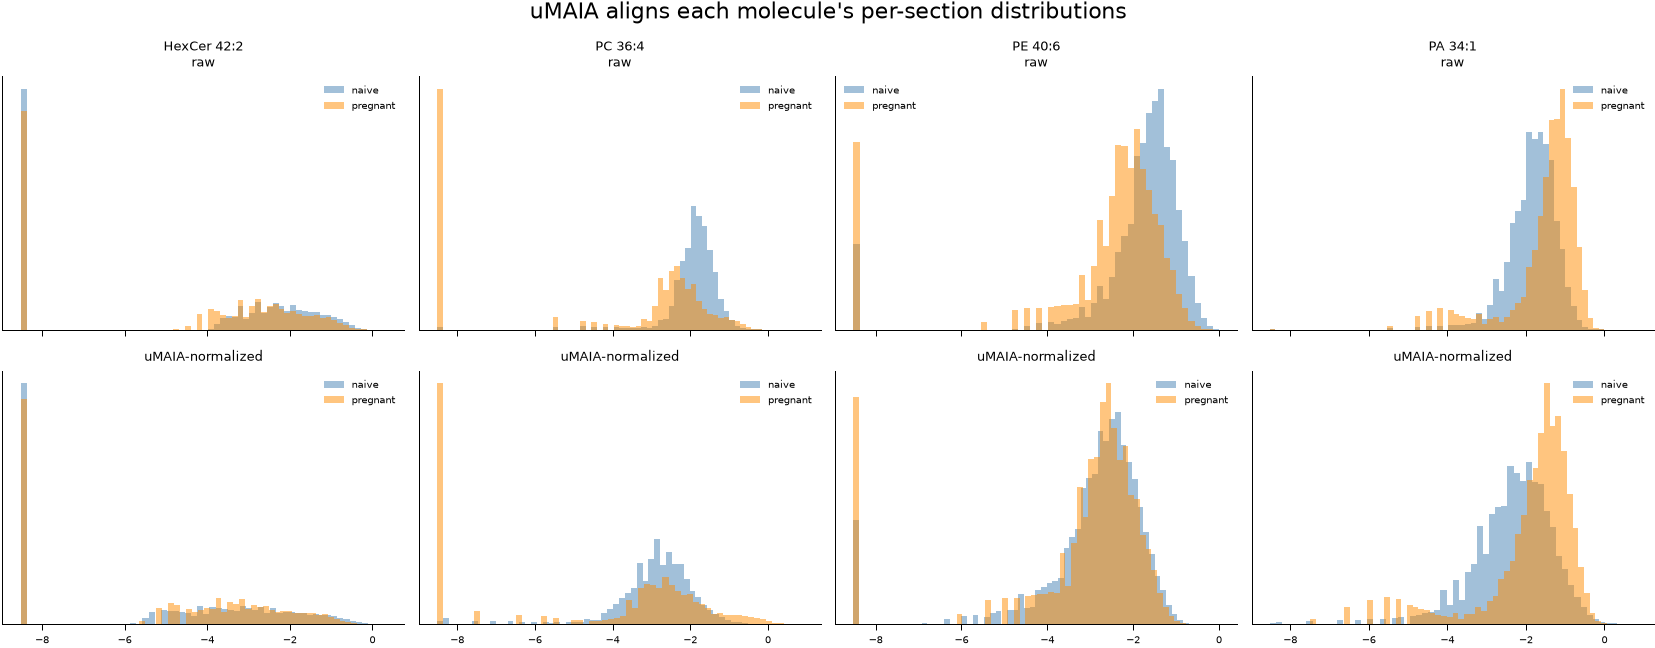

In [7]:
# before/after per-section histograms for a few molecules (this is the money plot)
show = ["HexCer 42:2", "PC 36:4", "PE 40:6", "PA 34:1"]
pick = [list(adata.var["lipid"]).index(s) for s in show]
fig, axes = plt.subplots(2, 4, figsize=(14, 5.6), sharex="col")
colours = ["steelblue", "darkorange"]
for col, v in enumerate(pick):
    for s in range(S):
        m = mask[:, s, v]                                  # real pixels of section s for molecule v
        axes[0, col].hist(x[m, s, v], bins=60, density=True, alpha=0.5, color=colours[s], label=sections[s])
        axes[1, col].hist(x_maia[m, s, v], bins=60, density=True, alpha=0.5, color=colours[s], label=sections[s])
    axes[0, col].set_title(f"{show[col]}\nraw", fontsize=FS["s"])
    axes[1, col].set_title("uMAIA-normalized", fontsize=FS["s"])
    for r in (0, 1):
        axes[r, col].set_yticks([]); axes[r, col].legend(fontsize=FS["xs"], frameon=False)
fig.suptitle("uMAIA aligns each molecule's per-section distributions", fontsize=FS["l"])
plt.tight_layout(); plt.show()

**check.** Top row: the two raw histograms for each molecule sit at visibly different places, the
slide-to-slide offset we have been warning about. Bottom row: after uMAIA, the same two distributions
overlap much better. The correction did not collapse them onto a single spike; it kept each section's
shape and slid them into register, which is exactly the conservative, order-preserving quantile matching
we will unroll by hand below. The alignment is not perfect, and with only two sections it should not be:
uMAIA cannot fully separate a genuine difference from a batch effect, so it leaves some real biology in
place rather than over-correcting.

🔬 **TASK.** Put one number on it. For every molecule, measure the gap between the two sections at
the **90th percentile** (a robust stand-in for where the foreground mode sits), then take the median of
that gap over all 104 molecules, before and after.

In [8]:
# quantify the cross-section offset: median over molecules of the 90th-percentile gap
def median_90pct_gap(arr):
    gaps = []
    for v in range(arr.shape[2]):
        per_section = [arr[mask[:, s, v], s, v] for s in range(arr.shape[1])]
        hi = [np.quantile(a, 0.9) for a in per_section if len(a)]
        if len(hi) == 2:
            gaps.append(abs(hi[0] - hi[1]))
    return float(np.median(gaps))

gap_raw = median_90pct_gap(x)
gap_norm = median_90pct_gap(x_maia)
print("median cross-section 90th-percentile gap")
print(f"  raw         : {gap_raw:.3f}  log units")
print(f"  uMAIA-norm  : {gap_norm:.3f}  log units")
print(f"  shrinkage   : {100 * (1 - gap_norm / gap_raw):.0f}%")

median cross-section 90th-percentile gap
  raw         : 0.211  log units
  uMAIA-norm  : 0.151  log units
  shrinkage   : 28%


**check.** The median 90th-percentile gap between the two sections drops from about **0.21** log
units on the raw data to about **0.15** after uMAIA, a cut of roughly a quarter to a third, across all 104
molecules at once. That is the batch offset being removed. Your exact figures will wobble by a hundredth
or two from run to run, because uMAIA subsamples about 2,500 pixels per section for the fit and that draw
is not fully seeded; the direction (a clear shrinkage) is the stable, reproducible part. The residual gap
is not zero, and it should not be: with only two sections uMAIA cannot tell a genuine
control-versus-pregnant difference from a batch effect, so it leaves real biology in place rather than
over-correcting. We unpack that trade-off in the corner-case section.

## does it recover the white-matter sphingolipid signal?

A shrinking median gap is reassuring, but it is an aggregate. The real test of a normalizer is
biological: a signal we *know* should look the same in both sections should, after correction, actually
look the same. Sphingolipids (the `HexCer`, `Cer` and `SM` classes) are concentrated in **myelin**, so
they light up the **white matter**: the corpus callosum, the fimbria, the internal capsule, the optic
tracts. Both our sections are normal adult brains cut at the same plane, so the white-matter
sphingolipid level should agree across them. On the raw data the batch effect spoils that agreement; a
good normalization should restore it.

We build a simple **composite sphingolipid score**: z-score each sphingolipid across pixels (so each
contributes on a common scale), then average. We compute it on the raw data and on the
uMAIA-normalized data, and compare the white-matter mean between the two sections. The gap between
sections should shrink after uMAIA.

7 sphingolipid ions | 11,147 white-matter pixels (6%)


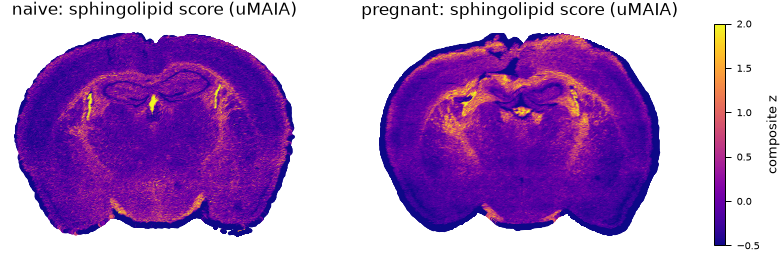

raw   : white-matter sphingo z   naive +0.250   pregnant +0.513   gap 0.262
uMAIA : white-matter sphingo z   naive +0.295   pregnant +0.445   gap 0.149


In [9]:
# reconstruct the per-pixel uMAIA values on the native (un-logged) scale, in adata's row order.
# adata is ordered naive-block then pregnant-block, so we stack the two sections the same way.
nC, nP = counts
umaia_native = np.vstack([np.exp(x_maia[:nC, 0, :]),     # naive pixels, section axis 0
                          np.exp(x_maia[:nP, 1, :])]      # pregnant pixels, section axis 1
                         ).astype(np.float32)
assert umaia_native.shape == X.shape

# sphingolipid columns + a white-matter pixel mask from the provided Allen acronyms
sph_cols = [i for i, n in enumerate(adata.var["lipid"]) if n.startswith(("HexCer", "Cer", "SM"))]
WM = {"cc", "fi", "int", "or", "ec", "alv", "fp", "df", "st", "opt", "ml", "py",
      "cpd", "arb", "em", "fx", "ccg", "scwm"}
wm = adata.obs["acronym"].astype(str).isin(WM).to_numpy()
print(f"{len(sph_cols)} sphingolipid ions | {wm.sum():,} white-matter pixels ({wm.mean():.0%})")

def sphingo_score(arr):                                   # z-score each sphingolipid, then average
    z = (arr - arr.mean(0)) / (arr.std(0) + 1e-9)
    return z[:, sph_cols].mean(1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sc = sphingo_score(umaia_native)
for ax, c in zip(axes, sections):
    m = (cond == c)
    sm = ax.scatter(adata.obs.loc[m, "zccf"], -adata.obs.loc[m, "yccf"], c=sc[m],
                    cmap=CMAP_SEQUENTIAL, vmin=-0.5, vmax=2.0, s=2, rasterized=True)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_title(f"{c}: sphingolipid score (uMAIA)", fontsize=FS["m"])
fig.colorbar(sm, ax=axes, shrink=0.6, label="composite z")
plt.show()

for label, arr in [("raw", X), ("uMAIA", umaia_native)]:
    s = sphingo_score(arr)
    nv = s[(cond == "naive") & wm].mean(); pg = s[(cond == "pregnant") & wm].mean()
    print(f"{label:6s}: white-matter sphingo z   naive {nv:+.3f}   pregnant {pg:+.3f}   gap {abs(nv - pg):.3f}")

**check.** The maps show the sphingolipid score lighting up the white-matter tracts in *both*
sections, the corpus callosum and fimbria glowing against a dark grey-matter background, which is the
correct anatomy. And the numbers tell the quantitative story: the white-matter sphingolipid gap between
the two sections, about **0.26** on the raw data, falls to roughly **0.10 to 0.18** after uMAIA (the
exact value shifts a little run to run with the subsampled fit). The technical
drift that made one slide's myelin look brighter than the other's is largely gone, and the shared
biology, high sphingolipids in white matter, now reads consistently across sections. That is uMAIA
recovering a signal we knew should be there. It is the single most convincing check that the
normalization did something real and not cosmetic.

## unrolling the correction: histogram matching by CDF and inverse-CDF

You called `uMAIA.norm.transform(...)` and watched the histograms align. Now we open that black box. The
transform is about twenty lines of NumPy and SciPy, and once you see it you will never find quantile
matching mysterious again. uMAIA does exactly this, only fit **jointly across all molecules at once**
with the modes learned from the MAP fit, whereas below we do it one molecule at a time so every step is
visible.

The idea. Suppose the measured log-intensity distribution of a lipid in one section has cumulative
distribution function $G(x)$, and we have a **reference** distribution with CDF $F$ that we want every
section to match. For any measured value $x$, $G(x)$ is its **quantile**: the fraction of pixels below
it, a number in $[0, 1]$. That quantile is the part we trust, because it encodes a pixel's *rank* within
its own section, which the batch effect does not change. To move the value onto the reference scale we
ask: what value in the reference distribution sits at that same quantile? That is $F^{-1}$, the inverse
CDF. So the whole correction is one composition:

$$x \;\longmapsto\; F^{-1}\big(G(x)\big).$$

Read it left to right: take a value, find its quantile under its own section's fitted CDF $G$, then read
off the value at that quantile under the shared reference $F$. Because it preserves quantiles, it is
**monotone**: it never reorders pixels within a section, it only restretches the axis. And because $G$
and $F$ are two-Gaussian mixtures, the stretch can be different in the foreground than in the
background, which is exactly what lets the correction hold the background anchor while sliding the
foreground mode. Let us build the two pieces.

💡 **HINT: read the code you are about to unroll.** The next cell rebuilds uMAIA's transform from scratch, but you should see the original first. Open **`uMAIA/normalization/_transform.py`** in your environment (`python -c "import uMAIA, os; print(os.path.dirname(uMAIA.__file__))"` prints the package root) and find `cdf_mixture` and `make_inv_cdf`: our three helpers below are line-for-line the same idea, only applied one molecule at a time so every step is visible. Reading uMAIA's version next to ours is the fastest way to convince yourself the `transform` call you already ran is exactly this $F^{-1}(G(x))$ map and nothing more.

In [10]:
# --- the two transparent pieces of uMAIA's histogram-matching correction ---
# (these mirror cdf_mixture / make_inv_cdf in uMAIA/normalization/_transform.py)

def cdf_mixture(x, mu1, mu2, sigma1, sigma2):
    # Equal-weight two-Gaussian mixture CDF: the average of two normal CDFs.
    # mu1/sigma1 describe the background mode, mu2/sigma2 the foreground mode.
    # G(x) returns the quantile of x under this fitted mixture.
    return (stats.norm.cdf(x, mu1, sigma1) + stats.norm.cdf(x, mu2, sigma2)) / 2.0

def make_inv_cdf(mu1, mu2, sigma1, sigma2, resolution=2000, rel_range=6):
    # Build F^{-1} for a reference mixture by tabulating its CDF and inverting it.
    # Lay a fine grid over the value axis (+/- 6 sigma around the two modes),
    # compute the mixture CDF on that grid, then interpolate the OTHER way:
    # from cdf value (a quantile) back to the value. interp1d gives us F^{-1}.
    mu_min, mu_max = min(mu1, mu2), max(mu1, mu2)
    sigma_max = max(sigma1, sigma2)
    domain = np.linspace(mu_min - rel_range * sigma_max,
                         mu_max + rel_range * sigma_max, resolution)
    cdf_vals = cdf_mixture(domain, mu1, mu2, sigma1, sigma2)
    return interp1d(cdf_vals, domain, bounds_error=False, fill_value="extrapolate", copy=True)

def transform_byicdf(x, mu1x, mu2x, sigma1x, sigma2x, icdf_ref):
    # The F^{-1}(G(x)) map: quantile under the source CDF, value under the reference.
    return icdf_ref(cdf_mixture(x, mu1x, mu2x, sigma1x, sigma2x))

print("built cdf_mixture, make_inv_cdf, transform_byicdf")

built cdf_mixture, make_inv_cdf, transform_byicdf


💡 **HINT.** `interp1d(cdf_vals, domain)` looks backwards at first glance, and that is exactly the
trick. A normal CDF maps value to quantile. By handing `interp1d` the quantiles as the x-argument and
the values as the y-argument, we get a function that maps quantile back to value, which is $F^{-1}$. The
`make_inv_cdf` in uMAIA does precisely this, on a 2000-point grid.

### a controlled demo: two mismatched histograms snapping into register

To *see* the mechanism cleanly, we first build a controlled example: two simulated sections of the same
lipid, each a background hump plus a foreground hump, where section B's foreground has been shifted and
stretched by a fake batch effect. This is exactly the situation on raw data, but with the truth known.
Then we apply the CDF/inverse-CDF map to push both onto a shared reference and watch the foreground modes
line up.

🔬 **TASK.** Simulate the two mismatched histograms.

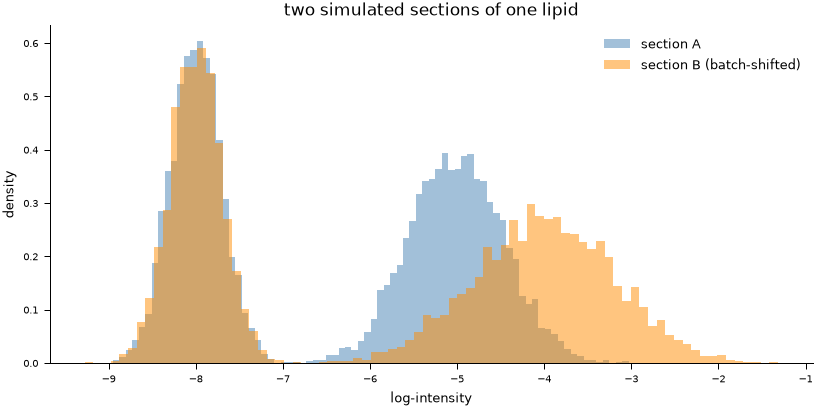

In [11]:
# --- simulate two sections of one lipid: a bg mode + a fg mode each, in LOG space ---
n = 8000
# section A: background at -8, foreground at -5 (this is "well-behaved")
muA_bg, muA_fg, sA_bg, sA_fg = -8.0, -5.0, 0.30, 0.55
# section B: SAME biology, but a batch effect shifted+stretched its FOREGROUND mode
muB_bg, muB_fg, sB_bg, sB_fg = -8.0, -4.0, 0.30, 0.80   # fg pushed right and widened

def sample_mixture(mu_bg, mu_fg, s_bg, s_fg, w_fg=0.55, n=n, seed=0):
    r = np.random.default_rng(seed)
    is_fg = r.random(n) < w_fg                          # per-pixel bg/fg label
    out = np.where(is_fg, r.normal(mu_fg, s_fg, n), r.normal(mu_bg, s_bg, n))
    return out

A = sample_mixture(muA_bg, muA_fg, sA_bg, sA_fg, seed=1)
B = sample_mixture(muB_bg, muB_fg, sB_bg, sB_fg, seed=2)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(A, bins=80, density=True, alpha=0.5, color="steelblue", label="section A")
ax.hist(B, bins=80, density=True, alpha=0.5, color="darkorange", label="section B (batch-shifted)")
ax.set_xlabel("log-intensity"); ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=FS["s"])
ax.set_title("two simulated sections of one lipid", fontsize=FS["m"])
plt.tight_layout(); plt.show()

**check.** The two background humps sit on top of each other near -8 (the stable anchor), but
section B's foreground hump is shoved right to -4 and is wider, while section A's sits at -5. That gap is
the batch effect we want gone.

🔬 **TASK.** Now build the **shared reference** the way uMAIA does (paper Eq 7): the reference mixture
parameters are the **mean over sections** of the fitted per-section parameters. With two sections that is
just the midpoint. Then map each section through $F_{ref}^{-1}(G_{section}(x))$.

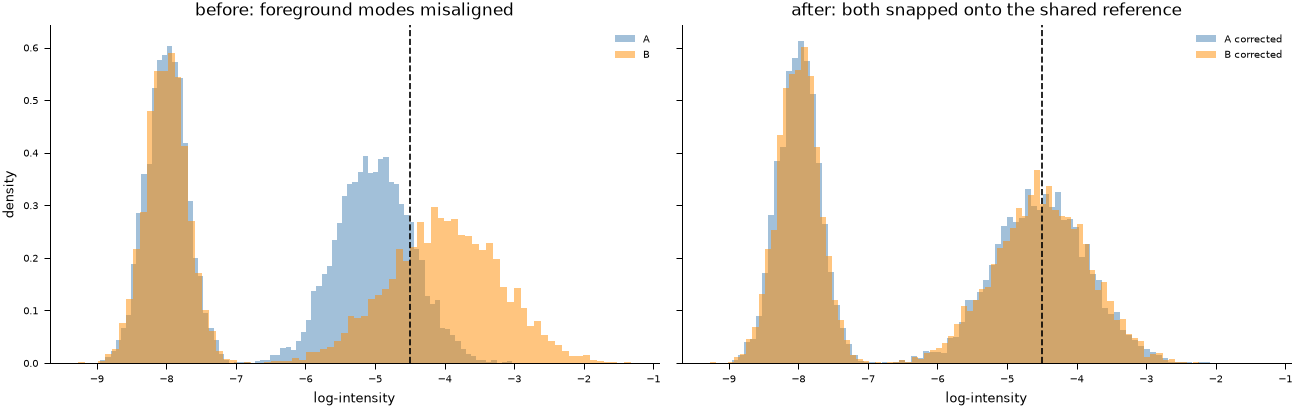

before: A fg median -5.01, B fg median -4.00
after:  A fg median -4.51, B fg median -4.50  (reference fg = -4.50)


In [12]:
# --- shared reference = mean of the two sections' fitted mixture parameters (Eq 7) ---
ref_bg = (muA_bg + muB_bg) / 2          # -8.0
ref_fg = (muA_fg + muB_fg) / 2          # -4.5, the midpoint of the two foreground modes
ref_s_bg = (sA_bg + sB_bg) / 2
ref_s_fg = (sA_fg + sB_fg) / 2

icdf_ref = make_inv_cdf(ref_bg, ref_fg, ref_s_bg, ref_s_fg)   # one reference inverse-CDF, shared

# push each section through its OWN CDF, then back through the reference inverse-CDF
A_corr = transform_byicdf(A, muA_bg, muA_fg, sA_bg, sA_fg, icdf_ref)
B_corr = transform_byicdf(B, muB_bg, muB_fg, sB_bg, sB_fg, icdf_ref)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
axes[0].hist(A, bins=80, density=True, alpha=0.5, color="steelblue", label="A")
axes[0].hist(B, bins=80, density=True, alpha=0.5, color="darkorange", label="B")
axes[0].axvline(ref_fg, color="k", ls="--", lw=1)
axes[0].set_title("before: foreground modes misaligned", fontsize=FS["m"]); axes[0].legend(frameon=False)
axes[0].set_xlabel("log-intensity"); axes[0].set_ylabel("density")
axes[1].hist(A_corr, bins=80, density=True, alpha=0.5, color="steelblue", label="A corrected")
axes[1].hist(B_corr, bins=80, density=True, alpha=0.5, color="darkorange", label="B corrected")
axes[1].axvline(ref_fg, color="k", ls="--", lw=1)
axes[1].set_title("after: both snapped onto the shared reference", fontsize=FS["m"]); axes[1].legend(frameon=False)
axes[1].set_xlabel("log-intensity")
plt.tight_layout(); plt.show()

print(f"before: A fg median {np.median(A[A>-6.5]):.2f}, B fg median {np.median(B[B>-6.5]):.2f}")
print(f"after:  A fg median {np.median(A_corr[A_corr>-6.5]):.2f}, "
      f"B fg median {np.median(B_corr[B_corr>-6.5]):.2f}  (reference fg = {ref_fg:.2f})")

**check.** After the transform, both foreground modes land on the dashed reference line at -4.5,
the midpoint, and the printed medians confirm it. The two distributions now overlap. We did not subtract
a constant or divide by a scalar; we matched quantiles through fitted CDFs, which lets the correction be
different in the foreground than in the background. The background anchor barely moved, the foreground
modes converged, and within each section every pixel kept its rank.

❓ **QUESTION.** The reference is the *average* of the two sections, so both move toward each other rather
than one snapping to the other. With only two sections, what happens to that reference if one slide is a
technical outlier? Hold that thought; it is the heart of the corner case below.

### the same mechanism on a real lipid

Now the real data, no simulation. We take `HexCer 42:2`, fit a two-component Gaussian mixture per section
on its log values (this stands in for uMAIA's per-molecule GMM init, finding the background and
foreground modes), build the midpoint reference, and apply the same CDF/inverse-CDF map. Because this
data is genuinely raw, the foreground offset you see is the real batch effect, and you can watch it
close.

In [13]:
import warnings
from sklearn.mixture import GaussianMixture
from sklearn.exceptions import ConvergenceWarning

demo_lipid = "HexCer 42:2"
jd = list(adata.var["lipid"]).index(demo_lipid)

# fit two modes per section on the LOG values. The background floor is a near-degenerate spike,
# so sklearn may warn it did not fully converge that thin component; the two mode MEANS are stable.
def fit_two_modes(log_x):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        g = GaussianMixture(n_components=2, random_state=RNG_SEED).fit(log_x.reshape(-1, 1))
    order = np.argsort(g.means_.ravel())                # lower mean = background, higher = foreground
    mu = g.means_.ravel()[order]; sd = np.sqrt(g.covariances_.ravel())[order]
    return mu[0], mu[1], sd[0], sd[1]                   # mu_bg, mu_fg, sigma_bg, sigma_fg

logs, params = {}, {}
for c in ["naive", "pregnant"]:
    m = (adata.obs["Condition"] == c).to_numpy()
    lv = np.log(np.clip(X[m, jd], 0, None) + eps)
    logs[c] = lv; params[c] = fit_two_modes(lv)
    print(f"{c:9s}: bg mu={params[c][0]:.2f}  fg mu={params[c][1]:.2f}")

print(f"\nbackground gap between sections: {abs(params['naive'][0]-params['pregnant'][0]):.3f}  (the anchor)")
print(f"foreground gap between sections: {abs(params['naive'][1]-params['pregnant'][1]):.3f}  (to be closed)")

ref = np.mean([params["naive"], params["pregnant"]], axis=0)     # Eq 7 midpoint for S=2
icdf_real = make_inv_cdf(ref[0], ref[1], ref[2], ref[3])
corr = {c: transform_byicdf(logs[c], *params[c], icdf_real) for c in ["naive", "pregnant"]}

naive    : bg mu=-8.52  fg mu=-2.19
pregnant : bg mu=-8.52  fg mu=-2.53

background gap between sections: 0.000  (the anchor)
foreground gap between sections: 0.346  (to be closed)


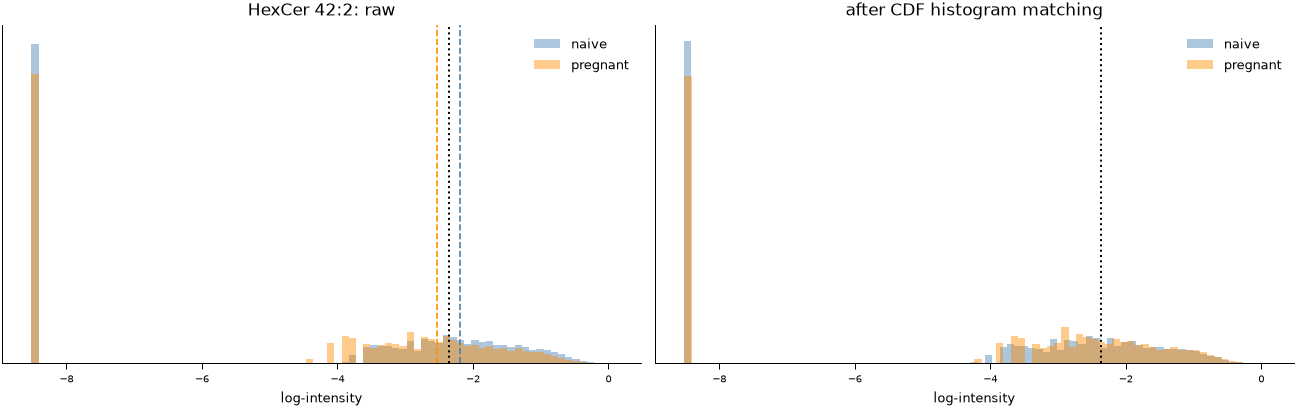

foreground median   naive -2.21 -> -2.38
foreground median   preg  -2.59 -> -2.42
reference foreground = -2.36


In [14]:
# before/after overlay on the REAL lipid
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
for c, colour in [("naive", "steelblue"), ("pregnant", "darkorange")]:
    axes[0].hist(logs[c], bins=80, density=True, alpha=0.45, color=colour, label=c)
    axes[1].hist(corr[c], bins=80, density=True, alpha=0.45, color=colour, label=c)
    axes[0].axvline(params[c][1], color=colour, ls="--", lw=1)   # each section's foreground mode
axes[0].axvline(ref[1], color="k", ls=":", lw=1.2)               # shared reference fg
axes[1].axvline(ref[1], color="k", ls=":", lw=1.2)
axes[0].set_title(f"{demo_lipid}: raw", fontsize=FS["m"]); axes[0].legend(frameon=False, fontsize=FS["s"])
axes[1].set_title("after CDF histogram matching", fontsize=FS["m"]); axes[1].legend(frameon=False, fontsize=FS["s"])
for ax in axes: ax.set_xlabel("log-intensity"); ax.set_yticks([])
plt.tight_layout(); plt.show()

def fg_median(v): return float(np.median(v[v > ref[0] + 1.0]))
print(f"foreground median   naive {fg_median(logs['naive']):.2f} -> {fg_median(corr['naive']):.2f}")
print(f"foreground median   preg  {fg_median(logs['pregnant']):.2f} -> {fg_median(corr['pregnant']):.2f}")
print(f"reference foreground = {ref[1]:.2f}")

**check.** This is the mechanism on real measurements. The two raw foreground modes start offset
(the dashed coloured lines), and after the transform both are pulled toward the black reference line,
their printed medians converging on it, while the background floors hold. Only the drifting mode moved,
the anchor stayed, and within each section every pixel kept its rank. That is the conservative,
non-linear rescaling uMAIA performs across all molecules jointly, here laid bare on one lipid.

## the honest corner case: uMAIA with only two sections

uMAIA was built for **stacks of many consecutive sections** of the same structure, dozens of slices
through a brain or a zebrafish, where biology varies smoothly from one section to the next and any sharp
section-to-section jump is almost certainly a batch effect. With that ensemble it can triangulate the
technical drift against the smooth biological trend. We are handing it **exactly two sections**, one
control and one pregnant. Several assumptions strain. Be honest about all of them.

1. **The reference is the mean of just two acquisitions.** Eq 7 averages the fitted foreground modes over
   sections; with two sections that is the midpoint of control and pregnant, with no larger ensemble to
   stabilize it. You saw this above: the reference sits exactly between the two and is pulled equally by
   both. If either slide were an outlier, the reference would follow it.

2. **No smoothness prior to lean on.** With many consecutive sections, uMAIA assumes biology changes
   slowly and high-frequency jumps are batch. With two sections there is no third slice to define
   "smooth", so the model cannot cleanly tell "section 2 is a different batch" from "section 2 is
   biologically different". The rank-1 `gamma_a * lambda_c` can, in principle, soak up a little of a
   genuine control-versus-pregnant difference and shrink it toward the shared reference.

3. **Subsampling needs enough pixels.** The fit subsamples about 2,500 pixels per section and will throw
   an error on a tiny region of interest. Our real sections have tens of thousands of tissue pixels each
   (about 89k and 100k), so this is fine; if you ever subset to a small ROI, set `subsample=False`.

The mitigations we adopt, and the reason for each:

- **We do not feed it the condition labels.** `covariate_vector` stays `None`. If we told the model
  "these pixels are pregnant", the per-condition `delta` could absorb the biological shift and we would
  normalize away the very effect we want to measure. So the normalizer never learns which slide is which
  condition.
- **We keep full-resolution sections** so the subsampling works.
- **We verify the before/after histograms by eye and check a known biological signal** (the white-matter
  sphingolipids), which is exactly what you just did.
- **We do the actual control-versus-pregnant statistics ourselves, afterwards**, with a transparent
  rank-sum test and Benjamini-Hochberg correction (a later notebook), run on the uMAIA-normalized,
  **non-Harmonized** data. We do not trust the model's internal `delta` to report the biology.

That last point is the cleanest one to remember. As the paper states, all differential testing and
downstream analysis is performed directly on the uMAIA output; the heavier batch integration (Harmony)
is used **only** for clustering, where strong coembedding is wanted, never for the differential test.
uMAIA here is a best-effort histogram alignment that removes gross slide-to-slide offset. It is
operating outside its comfort zone with two sections, and we compensate by being careful downstream.
This is the honest, slightly dirty part of the pipeline, and now you know exactly where the dirt is.

## a second, separate normalization: per-lipid 0-to-1 scaling

uMAIA made the same *lipid* comparable across *sections*. There is a second, independent problem:
different *lipids* are not comparable to each other on the raw intensity scale. The reason is physical.
MALDI is only **semi-quantitative**: a lipid's measured intensity depends on how easily it ionizes,
which varies wildly from one molecule to another. A lipid that ionizes efficiently reads bright even at
modest abundance; a poor ionizer reads dim even when it is abundant. So you cannot read "lipid X is 0.08
and lipid Y is 0.20, therefore there is more Y". The numbers live on different, lipid-specific scales.

The fix is to put every lipid on a common yardstick: clip the extreme tails and rescale each lipid into
[0, 1], so a value of 0.7 means "high *for this lipid*" regardless of which lipid it is. That is the only
sense in which MALDI intensities compare across molecules, and it is what every cross-lipid step later in
the course runs on. It is a different operation from uMAIA, applied later (in the embedding notebook),
and we unroll it here so you have seen it.

💡 **HINT.** The unrolled cell below is identical to **`cl.analysis.min01_per_lipid`**; open `src/cajal_lipidomics/analysis.py`, read that function, and confirm the clip-and-rescale you write by hand is exactly what the helper does before you trust the `assert` that checks it.

In [15]:
# --- per-lipid 0-1 normalization, unrolled (this is exactly cl.analysis.min01_per_lipid) ---
# we run it on the uMAIA-normalized values, the scale everything downstream uses
Xn = umaia_native.astype(float)
lo, hi = 0.005, 0.995                              # clip the extreme 0.5% tails per lipid
ql = np.quantile(Xn, lo, axis=0)                   # per-lipid low clip (one value per column)
qh = np.quantile(Xn, hi, axis=0)                   # per-lipid high clip
span = np.where(qh > ql, qh - ql, 1.0)             # guard against a flat (constant) lipid
X01 = np.clip((Xn - ql) / span, 0, 1)              # rescale each lipid into [0, 1]

# the helper does exactly the same thing; verify they agree
X01_helper = analysis.min01_per_lipid(umaia_native, lo=0.005, hi=0.995)
print("max abs difference between unrolled and helper:", float(np.max(np.abs(X01 - X01_helper))))
assert np.allclose(X01, X01_helper), "helper and unrolled version should match"
print("they match: cl.analysis.min01_per_lipid is the unrolled recipe above")

max abs difference between unrolled and helper: 0.0
they match: cl.analysis.min01_per_lipid is the unrolled recipe above


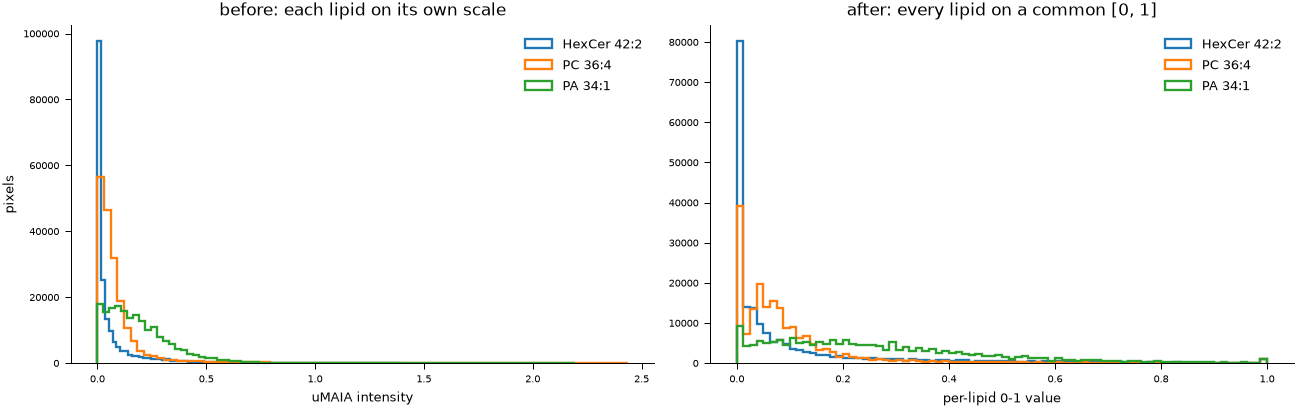

In [16]:
# see the scale collapse: three lipids before (very different ranges) and after ([0,1])
show3 = ["HexCer 42:2", "PC 36:4", "PA 34:1"]
cols = [list(adata.var["lipid"]).index(s) for s in show3]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for c, name in zip(cols, show3):
    axes[0].hist(Xn[:, c], bins=80, histtype="step", lw=1.4, label=name)
    axes[1].hist(X01[:, c], bins=80, histtype="step", lw=1.4, label=name)
axes[0].set_title("before: each lipid on its own scale", fontsize=FS["m"])
axes[0].set_xlabel("uMAIA intensity"); axes[0].set_ylabel("pixels"); axes[0].legend(fontsize=FS["s"], frameon=False)
axes[1].set_title("after: every lipid on a common [0, 1]", fontsize=FS["m"])
axes[1].set_xlabel("per-lipid 0-1 value"); axes[1].legend(fontsize=FS["s"], frameon=False)
plt.tight_layout(); plt.show()

**check.** Before, the three lipids live on visibly different ranges, so a raw cross-lipid
comparison would be meaningless. After, all three fill the same [0, 1] axis, and 0.7 means "high for this
lipid" no matter which lipid it is.

❓ **QUESTION.** Per-lipid 0-1 scaling and uMAIA normalization solve *different* problems. State each in
one sentence. (uMAIA: make the same lipid comparable across sections. min01: make different lipids
comparable to each other.) Both are necessary; neither replaces the other.

## saving your output for the next notebook

This is your N3 deliverable: the two sections, made comparable. We store the uMAIA-normalized values as
a **layer** on the AnnData (`adata.layers["umaia"]`, on the native scale) and keep the raw `X` untouched,
then write `data/derived/03_normalized.h5ad`. The next notebook loads exactly this file and builds the
embedding on the uMAIA layer. Each notebook consumes the previous stage, so the course runs as one
sequential pipeline.

🔬 **TASK.** Attach the layer and write the file.

In [17]:
# attach the uMAIA-normalized layer (native scale, same row order as adata) and save
adata.layers["umaia"] = umaia_native
out = os.path.join(DATA, "derived", "03_normalized.h5ad")
adata.write_h5ad(out)
print("saved", out)
print("layers now:", list(adata.layers.keys()))
print("X (raw) unchanged:", float(np.asarray(adata.X).min()), "to", float(np.asarray(adata.X).max()))
print("umaia layer range:", float(adata.layers["umaia"].min()), "to", float(adata.layers["umaia"].max()))

saved /home/fusar/lipidomics_tutorial_cajalcourse/data/derived/03_normalized.h5ad
layers now: ['umaia']
X (raw) unchanged: 0.0 to 1.0
umaia layer range: 0.000199017915292643 to 37.87334060668945


**check.** `data/derived/03_normalized.h5ad` is written, with `layers` now listing `umaia`, the raw
`X` still on its 0-to-1 scale, and the `umaia` layer on its native (un-logged) scale. That file is the
input to N4.

## what you did, in one breath

You met the **batch effect** and saw why it is dangerous: the same lipid reads a different raw intensity
on different slides for purely technical reasons, so a naive control-versus-pregnant comparison would
partly measure the slide. You saw the empirical fact uMAIA stands on, the **bimodal log histogram** with
a stable background anchor and a drifting foreground mode. You read the **model**: a two-Gaussian mixture
per (lipid, section) whose foreground mean carries a **rank-1 batch shift** `gamma_a * lambda_c`, fit by
**MAP via SVI**, not by sampling. You built uMAIA's input tensor from your own annotated AnnData and
**ran the real fit**, watched the median cross-section offset shrink by about a third, and confirmed that
the **white-matter sphingolipid signal lines up** across sections afterwards. You unrolled the
**correction** by hand, pushing each value through its own CDF to a quantile and back through a shared
reference inverse-CDF, in simulation and on a real lipid. You faced the **two-section corner case**
honestly. And you applied the second, separate normalization, **per-lipid 0-to-1 scaling**.

Two rules to carry forward:

- **uMAIA makes the same lipid comparable across sections; min01 makes different lipids comparable to
  each other.** Different problems, both necessary.
- **Differential testing runs on the uMAIA-normalized, non-Harmonized data.** Never test on data whose
  batch correction also touched the biology, and with only two sections, never hand the normalizer the
  condition labels.

Next, in N4, we use this comparable data to build the embedding and start finding the lipid territories
called lipizones.